In [1]:
cross_language_results = {}

In [44]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [45]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 1
%aimport cowaver.utils
%aimport cowaver.datasets
%aimport cowaver.datamodules
%aimport cowaver.models
%aimport cowaver.modules
%aimport cowaver.modules.architectures
%aimport cowaver.checkpoints
%aimport cowaver.transforms

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Constantes

In [46]:
from pathlib import Path
from cowaver.utils import encontrar_dispositivo

DEVICE = encontrar_dispositivo()
DATASET_SIZE = 480
LANGUAGE = "french"

cross_language_results[LANGUAGE] = {}

# Rutas a los datos
workspace_path = Path("../") / LANGUAGE
compressed_phones_path = workspace_path / f"kalulu-phones-{DATASET_SIZE}.tar.xz"
compressed_spoken_path = workspace_path / f"kalulu-spoken-{DATASET_SIZE}.tar.xz"

# Carpeta donde se descomprimirán los datos
data_path = workspace_path / "data"

# Carpeta donde se guardan los checkpoints
checkpoints_path = workspace_path / "checkpoints" / str(DATASET_SIZE)

Buscando dispositivo... MPS


### Funciones utilitarias

### Funciones de graficado

In [47]:
import io
import ipywidgets as widgets
import torchaudio
import torch
import matplotlib.pyplot as plt
import numpy as np
from cowaver.utils import AUDIO_SAMPLE_RATE
from cowaver.models import TrainHistory, TestResults

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

def plot_waveform(waveform, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if waveform.dim() == 2:
        waveform = waveform[0]

    waveform = waveform.detach().cpu()
    time = torch.arange(len(waveform)) / AUDIO_SAMPLE_RATE

    ax.plot(time.numpy(), waveform.numpy())
    ax.set_title("Forma de onda")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")
    ax.grid(True)

    if should_show:
        plt.show()

def plot_image(image, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if image.dim() == 5:
        image = image[0, 0]      # [S,B,C,H,W] -> primera imagen
    elif image.dim() == 4:
        image = image[0]         # [B,C,H,W] -> primera imagen
    elif image.dim() != 3:
        raise ValueError(f"Unexpected image shape: {image.shape}")

    image = image.detach().cpu()

    ax.imshow(image.clamp(0, 1).permute(1, 2, 0))
    ax.set_title("Imagen")
    # ax.axis("off")

    if should_show:
        plt.show()

def plot_train_history(train_history: TrainHistory, subfig=None, should_show: bool = True):
    if subfig is None:
        _, ax = plt.subplots(figsize=(8, 3), layout="constrained")
    else:
        ax = subfig.subplots()
    epochs = range(1, train_history.num_epochs + 1)
    ax.plot(epochs, train_history.train_losses, label="Train")
    ax.plot(epochs, train_history.val_losses, "r", label="Validation")
    ax.set_title("Train vs Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()
    if should_show:
        plt.show()

def plot_logits(logits, classes, subfig=None):
    if subfig is None:
        fig = plt.figure(figsize=(8, 3), layout="constrained")
        subfig = fig.subfigures()
        should_show = True
    else:
        should_show = False

    topk_values, topk_indices = torch.topk(logits.detach().cpu().squeeze(), k=5)
    topk_classes = [classes[i] for i in topk_indices.cpu().numpy()]

    logits, classes = topk_values, topk_classes
    
    values = logits.squeeze().numpy()
    order = np.argsort(values)[::-1]
    sorted_classes  = [classes[i] for i in order]
    sorted_values = values[order]

    ax = subfig.subplots()
    ax.plot(sorted_classes, sorted_values, marker='o')
    ax.set_title("Logits")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    if should_show:
        plt.show()

def plot_test_results(test_results: TestResults | list, should_show: bool = True):
    plt.figure(figsize=(10, 3), layout="constrained")
    if isinstance(test_results, TestResults):
        plt.bar(["top1", "top3", "top5"], [test_results.top1, test_results.top3, test_results.top5])
    else:
        plt.plot(range(len(test_results)), list(map(lambda x: x.top1, test_results)), 'r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top3, test_results)), '--r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top5, test_results)), ':r')
        plt.legend(["top1", "top3", "top5"])
    plt.title("Test Accuracy")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.grid(True, linestyle="--", alpha=0.6)
    if should_show:
        plt.show()

def plot_activation(activation, ax=None, vmin=-3, vmax=3):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if activation.dim() == 4:
        activation = activation[0, 0]
    elif activation.dim() == 3:
        activation = activation[0]
    elif activation.dim() != 2:
        raise ValueError(f"Unexpected activation shape: {activation.shape}")

    activation = activation.detach().cpu()

    im = ax.imshow(
        activation.numpy(),
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_title("Activación")
    ax.set_xlabel("Dimensión")
    ax.set_ylabel("Ventana")
    ax.set_xticks([0, activation.size(1) - 1])
    ax.set_yticks([0, activation.size(0) - 1])

    if should_show:
        plt.colorbar(im, ax=ax)
        plt.show()

    return im
        
def plot_mel(mel, ax=None, should_show: bool = False):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")

    if mel.dim() == 4:
        mel = mel[0, 0]       # [B,1,mel_bins,T]
    elif mel.dim() == 3:
        mel = mel[0]          # [B,mel_bins,T] o [1,mel_bins,T]
    elif mel.dim() != 2:
        raise ValueError(f"Unexpected mel shape: {mel.shape}")

    mel = torch.expm1(mel).clamp_min(0)
    mel = mel.detach().cpu()

    ax.imshow(
        mel.numpy(),
        cmap="coolwarm",
        aspect="auto",
        origin="lower", interpolation="nearest"
    )

    ax.set_title("Mel Spectrogram")
    ax.set_xlabel("Time Frame")
    ax.set_ylabel("Mel-bin Index")
    ax.set_xticks([0, mel.size(1) - 1])
    ax.set_yticks([0, mel.size(0) - 1])

    if should_show:
        plt.show()


def plot_pca(scores: torch.Tensor, labels: list | None):
    """Grafica una proyección PCA bidimensional.

    Parameters
    ----------
    scores: Tensor
        Tensor de forma [B, q], donde B es el número de ejemplos.
        Se grafican las dos primeras componentes.

    labels: list | None
        Lista opcional de etiquetas, una por ejemplo. Si se proporciona,
        debe tener largo B.
    """
    
    scores = scores.detach().cpu()

    if labels is not None and len(labels) != scores.size(0):
        raise ValueError("labels debe tener el mismo largo que scores.")
    
    plt.figure(figsize=(6, 6))
    plt.scatter(scores[:, 0], scores[:, 1])
    if labels is not None:
        for i, label in enumerate(labels):
            plt.text(scores[i, 0].item(), scores[i, 1].item(), label, fontsize=9)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA")
    plt.grid(True)
    plt.show()

## Preparación del entorno

In [48]:
from cowaver.utils import descomprimir_archivo, listar_clases, separar_clases

phones_path = descomprimir_archivo(compressed_phones_path, data_path)
spoken_path = descomprimir_archivo(compressed_spoken_path, data_path)

palabras = listar_clases(phones_path / "train")

print("Palabras: ", len(palabras))

palabras_a_entrenar, palabras_a_generalizar = separar_clases(palabras, fraction=0.2)
print("Palabras a entrenar:", len(palabras_a_entrenar))
print(f"Palabras a generalizar ({len(palabras_a_generalizar)}):", palabras_a_generalizar)

Descomprimiendo ../french/kalulu-phones-480.tar.xz en ../french/data/kalulu-phones-480... YA EXISTE
Descomprimiendo ../french/kalulu-spoken-480.tar.xz en ../french/data/kalulu-spoken-480... YA EXISTE
Palabras:  480
Palabras a entrenar: 384
Palabras a generalizar (96): ['abeille', 'aigle', 'aile', 'après', 'arc', 'assise', 'auto', 'avez', 'avion', 'base', 'bien', 'bête', 'cage', 'chasse', 'chaud', 'cirque', 'colle', 'colère', 'cousin', 'dent', 'devant', 'domino', 'doux', 'désert', 'filet', 'fine', 'foyer', 'gagnant', 'gagné', 'gare', 'grotte', 'guide', 'jambe', 'jardin', 'jouant', 'jour', 'karaté', 'leçon', 'loup', 'lundi', 'malade', 'marine', 'masque', 'monstre', 'moule', 'mousse', 'météo', 'neveu', 'niche', 'niveau', 'noté', 'noyer', 'nul', 'onze', 'ours', 'passé', 'pendant', 'perdu', 'petit', 'phrase', 'piano', 'pin', 'piqué', 'pirate', 'porte', 'porter', 'pâte', 'quart', 'que', 'radio', 'reine', 'renard', 'reste', 'riant', 'rouge', 'savoir', 'ses', 'soleil', 'station', 'sujet', 'sèc

## Autoencoder

In [49]:
import torch
from torch import nn

def cout(x, layer):
  """
  Unnecessarily complicated but complete way to
  calculate the output depth, height
  and width size for a Conv2D layer

  Args:
    x: tuple
      Input size (depth, height, width)
    layer: nn.Conv2d
      The Conv2D layer

  Returns:
    Tuple of out-depth/out-height and out-width
    Output shape as given in [Ref]
    Ref:
    https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
  """
  assert isinstance(layer, nn.Conv2d)
  p = layer.padding if isinstance(layer.padding, tuple) else (layer.padding,)
  k = layer.kernel_size if isinstance(layer.kernel_size, tuple) else (layer.kernel_size,)
  d = layer.dilation if isinstance(layer.dilation, tuple) else (layer.dilation,)
  s = layer.stride if isinstance(layer.stride, tuple) else (layer.stride,)
  in_depth, in_height, in_width = x
  out_depth = layer.out_channels
  out_height = 1 + (in_height + 2 * p[0] - (k[0] - 1) * d[0] - 1) // s[0]
  out_width = 1 + (in_width + 2 * p[-1] - (k[-1] - 1) * d[-1] - 1) // s[-1]
  return (out_depth, out_height, out_width)
    
class BiasLayer(nn.Module):
  """
  Bias Layer
  """

  def __init__(self, shape):
    """
    Initialise parameters of bias layer

    Args:
      shape: tuple
        Requisite shape of bias layer

    Returns:
      Nothing
    """
    super(BiasLayer, self).__init__()
    init_bias = torch.zeros(shape)
    self.bias = nn.Parameter(init_bias, requires_grad=True)

  def forward(self, x):
    """
    Forward pass

    Args:
      x: torch.tensor
        Input features

    Returns:
      Output of bias layer
    """
    return x + self.bias
      
class ConvAutoEncoder(nn.Module):
  """
  A Convolutional AutoEncoder
  """

  def __init__(self, x_dim, h_dim, n_filters=32, filter_size=5):
    """
    Initialize parameters of ConvAutoEncoder

    Args:
      x_dim: tuple
        Input dimensions (channels, height, widths)
      h_dim: int
        Hidden dimension, bottleneck dimension, K
      n_filters: int
        Number of filters (number of output channels)
      filter_size: int
        Kernel size

    Returns:
      Nothing
    """
    super().__init__()
    channels, height, widths = x_dim

    # Encoder input bias layer
    self.enc_bias = BiasLayer(x_dim)

    # First encoder conv2d layer
    self.enc_conv_1 = nn.Conv2d(channels, n_filters, filter_size)

    # Output shape of the first encoder conv2d layer given x_dim input
    conv_1_shape = cout(x_dim, self.enc_conv_1)

    # Second encoder conv2d layer
    self.enc_conv_2 = nn.Conv2d(n_filters, n_filters, filter_size)

    # Output shape of the second encoder conv2d layer given conv_1_shape input
    conv_2_shape = cout(conv_1_shape, self.enc_conv_2)

    # The bottleneck is a dense layer, therefore we need a flattenning layer
    self.enc_flatten = nn.Flatten()

    # Conv output shape is (depth, height, width), so the flatten size is:
    flat_after_conv = conv_2_shape[0] * conv_2_shape[1] * conv_2_shape[2]

    # Encoder Linear layer
    self.enc_lin = nn.Linear(flat_after_conv, h_dim)

    # Decoder Linear layer
    self.dec_lin = nn.Linear(h_dim, flat_after_conv)

    # Unflatten data to (depth, height, width) shape
    self.dec_unflatten = nn.Unflatten(dim=-1, unflattened_size=conv_2_shape)

    # First "deconvolution" layer
    self.dec_deconv_1 = nn.ConvTranspose2d(n_filters, n_filters, filter_size)

    # Second "deconvolution" layer
    self.dec_deconv_2 = nn.ConvTranspose2d(n_filters, channels, filter_size)

    # Decoder output bias layer
    self.dec_bias = BiasLayer(x_dim)

  def encode(self, x):
    """
    Encoder

    Args:
      x: torch.tensor
        Input features

    Returns:
      h: torch.tensor
        Encoded output
    """
    s = self.enc_bias(x)
    s = F.relu(self.enc_conv_1(s))
    s = F.relu(self.enc_conv_2(s))
    s = self.enc_flatten(s)
    h = self.enc_lin(s)
    return h

  def decode(self, h):
    """
    Decoder

    Args:
      h: torch.tensor
        Encoded output

    Returns:
      x_prime: torch.tensor
        Decoded output
    """
    s = F.relu(self.dec_lin(h))
    s = self.dec_unflatten(s)
    s = F.relu(self.dec_deconv_1(s))
    s = self.dec_deconv_2(s)
    x_prime = self.dec_bias(s)
    return x_prime

  def forward(self, x):
    """
    Forward pass

    Args:
      x: torch.tensor
        Input features

    Returns:
      Decoded output
    """
    return self.decode(self.encode(x))

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import LRScheduler, LinearLR

from cowaver.modules.adapters import build_temporal_adapter
from cowaver.modules.common import unpack_batch
from cowaver.modules.decoders import build_decoder
from cowaver.modules.encoders import AvgPooledITEncoder
from cowaver.models import DataModule, TestResults, TrainProgramme, TrainableModule
from cowaver.utils import distancia_mel
    
class TrainableAutoencoder(TrainableModule):
    def __init__(self, seq_len: int = 49, mel_bins: int = 80):
        super().__init__(name=f"autoencoder_sl{seq_len}_mb{mel_bins}")
        self.seq_len = seq_len
        self.mel_bins = mel_bins
        self.autoencoder = ConvAutoEncoder(x_dim=(1, seq_len, mel_bins), h_dim=256, n_filters=32, filter_size=5)
        
    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        return self.autoencoder(x)

    def training_step(self, batch, batch_idx, phase: int):
        (x, y), labels, task_ids = batch
        B = x.size(0)
        y = y.transpose(2, 3)
        y_hat = self(y)
        return F.mse_loss(y_hat.reshape(B, -1), target=y.reshape(B, -1))

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (x, y), targets, task_ids = batch
        y = y.transpose(2, 3)
        y_hat = self(y)
        y_hat = y_hat.squeeze(1).transpose(1, 2)
        
        prototypes = data.mel_prototypes(y_hat.device)

        distances = distancia_mel(y_hat, prototypes)

        k = min(5, distances.size(1))
        topk = distances.topk(k, dim=1, largest=False).indices

        targets = targets.view(-1, 1)

        top1 = (topk[:, :1] == targets).any(dim=1).sum().item()
        top3 = (topk[:, :min(3, k)] == targets).any(dim=1).sum().item()
        top5 = (topk[:, :k] == targets).any(dim=1).sum().item()

        return TestResults(top1=top1, top3=top3, top5=top5)

    def inference_step(self, batch: tuple) -> tuple[Tensor, Tensor]:
        x, _, _, task_ids = unpack_batch(batch)
        return self(x, task_ids=task_ids)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        trainable_params = filter(lambda p: p.requires_grad, self.parameters())
        return AdamW(params=trainable_params, lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        start_epoch = programme.epochs_before_phase(phase)
        for group in optimizer.param_groups:
            group.setdefault("initial_lr", group["lr"])
        return LinearLR(
            optimizer,
            start_factor=1.0,
            end_factor=programme.end_factor,
            total_iters=programme.decay_epochs(),
            last_epoch=start_epoch - 1,
        )

In [51]:
from cowaver.datamodules import TinyMel
from cowaver.models import TrainProgramme
from cowaver.utils import entrenar_red
from cowaver.utils import guardar_checkpoint

net = TrainableAutoencoder()

spoken_data = TinyMel(spoken_path, mel_bins=80, classes=palabras)

programme = TrainProgramme(
    theta_max=30,
    num_phases=1,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4
)

# Uncomment to train
#
# train_history = entrenar_red(net=net, data=spoken_data, programme=programme, phase=1, dispositivo=DEVICE)
# guardar_checkpoint(net, train_history=train_history, programme=programme, folder=checkpoints_path / "spoken")

En español:

```
=================================================
Red autoencoder_sl49_mb80 | fase 1
=================================================
Epoch 1/30 | train_loss=18.3030 | val_loss=0.6247
Epoch 2/30 | train_loss=0.6672 | val_loss=0.5356
Epoch 3/30 | train_loss=0.5393 | val_loss=0.3875
Epoch 4/30 | train_loss=0.4438 | val_loss=0.4090
Epoch 5/30 | train_loss=0.3898 | val_loss=0.4069
Epoch 6/30 | train_loss=0.2793 | val_loss=0.2599
Epoch 7/30 | train_loss=0.2869 | val_loss=0.2404
Epoch 8/30 | train_loss=0.2448 | val_loss=0.2820
Epoch 9/30 | train_loss=0.2168 | val_loss=0.2117
Epoch 10/30 | train_loss=0.2127 | val_loss=0.1845
Epoch 11/30 | train_loss=0.1752 | val_loss=0.2257
Epoch 12/30 | train_loss=0.1712 | val_loss=0.1657
Epoch 13/30 | train_loss=0.1671 | val_loss=0.2181
Epoch 14/30 | train_loss=0.1394 | val_loss=0.1535
Epoch 15/30 | train_loss=0.1402 | val_loss=0.1381
Epoch 16/30 | train_loss=0.1241 | val_loss=0.1792
Epoch 17/30 | train_loss=0.1235 | val_loss=0.1532
Epoch 18/30 | train_loss=0.1168 | val_loss=0.1422
Epoch 19/30 | train_loss=0.1075 | val_loss=0.1238
Epoch 20/30 | train_loss=0.0979 | val_loss=0.1170
Epoch 21/30 | train_loss=0.0906 | val_loss=0.1126
Epoch 22/30 | train_loss=0.0865 | val_loss=0.1103
Epoch 23/30 | train_loss=0.0834 | val_loss=0.1082
Epoch 24/30 | train_loss=0.0809 | val_loss=0.1071
Epoch 25/30 | train_loss=0.0787 | val_loss=0.1054
Epoch 26/30 | train_loss=0.0767 | val_loss=0.1046
Epoch 27/30 | train_loss=0.0769 | val_loss=0.1060
Epoch 28/30 | train_loss=0.0761 | val_loss=0.1047
Epoch 29/30 | train_loss=0.0751 | val_loss=0.1045
Epoch 30/30 | train_loss=0.0742 | val_loss=0.1031
Phase 1 | test_loss=0.0920
Guardando checkpoint en ../spanish/480/checkpoints/spoken/autoencoder_sl49_mb80_1st_phase.pt... OK
```

En francés:

```
=================================================
Red autoencoder_sl49_mb80_ds480 | fase 1
=================================================
Epoch 1/30 | train_loss=3.2226 | val_loss=0.7540
Epoch 2/30 | train_loss=0.6123 | val_loss=0.5605
Epoch 3/30 | train_loss=0.5450 | val_loss=0.5499
Epoch 4/30 | train_loss=0.3820 | val_loss=0.2591
Epoch 5/30 | train_loss=0.2879 | val_loss=0.6196
Epoch 6/30 | train_loss=0.3023 | val_loss=0.2533
Epoch 7/30 | train_loss=0.2473 | val_loss=0.2190
Epoch 8/30 | train_loss=0.1754 | val_loss=0.1545
Epoch 9/30 | train_loss=0.1727 | val_loss=0.1432
Epoch 10/30 | train_loss=0.1453 | val_loss=0.1589
Epoch 11/30 | train_loss=0.1384 | val_loss=0.1281
Epoch 12/30 | train_loss=0.1157 | val_loss=0.1324
Epoch 13/30 | train_loss=0.1051 | val_loss=0.1070
Epoch 14/30 | train_loss=0.0941 | val_loss=0.0967
Epoch 15/30 | train_loss=0.0880 | val_loss=0.0941
Epoch 16/30 | train_loss=0.0748 | val_loss=0.0892
Epoch 17/30 | train_loss=0.0706 | val_loss=0.0850
Epoch 18/30 | train_loss=0.0657 | val_loss=0.0829
Epoch 19/30 | train_loss=0.0610 | val_loss=0.0802
Epoch 20/30 | train_loss=0.0571 | val_loss=0.0775
Epoch 21/30 | train_loss=0.0536 | val_loss=0.0753
Epoch 22/30 | train_loss=0.0517 | val_loss=0.0740
Epoch 23/30 | train_loss=0.0503 | val_loss=0.0732
Epoch 24/30 | train_loss=0.0491 | val_loss=0.0726
Epoch 25/30 | train_loss=0.0478 | val_loss=0.0719
Epoch 26/30 | train_loss=0.0468 | val_loss=0.0709
Epoch 27/30 | train_loss=0.0458 | val_loss=0.0706
Epoch 28/30 | train_loss=0.0449 | val_loss=0.0697
Epoch 29/30 | train_loss=0.0439 | val_loss=0.0690
Epoch 30/30 | train_loss=0.0430 | val_loss=0.0688
Phase 1 | test_loss=0.0666
Guardando checkpoint en ../french/480/checkpoints/spoken/autoencoder_sl49_mb80_ds480_1st_phase.pt... OK
```

Palabras entrenadas (480): Top-1: 96.88% | Top-3: 99.79% | Top-5: 99.79%


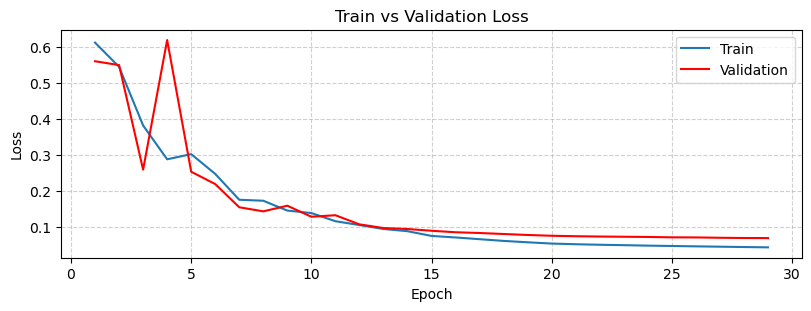

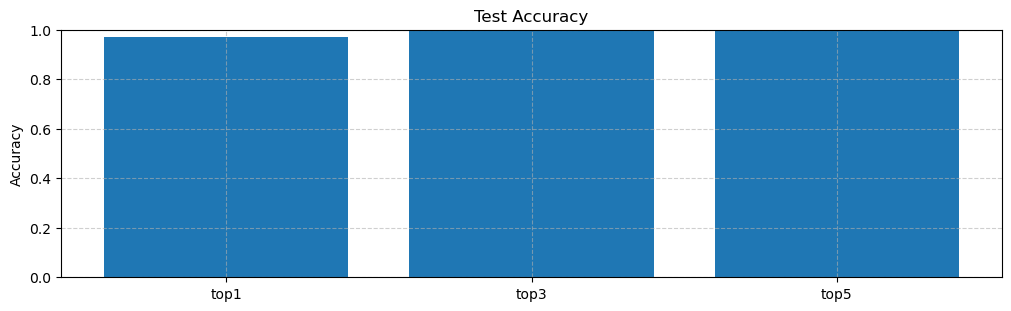

In [52]:
from cowaver.datamodules import TinyMel
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint

net = TrainableAutoencoder()
train_history = cargar_checkpoint(net, folder=checkpoints_path / "spoken", silent=True)

train_history.train_losses = train_history.train_losses[1:]
train_history.val_losses = train_history.val_losses[1:]
plot_train_history(train_history, should_show=False)
plt.savefig(f"{LANGUAGE}_autoencoder_train.svg")
cross_language_results[LANGUAGE]["autoencoder_train"] = train_history

spoken_data = TinyMel(spoken_path, mel_bins=80, classes=palabras)
test_results = evaluar_red(net, spoken_data)
print(f"Palabras entrenadas ({int(DATASET_SIZE)}): {test_results}")

plot_test_results(test_results, should_show=False)
plt.savefig(f"{LANGUAGE}_autoencoder_test.svg")
cross_language_results[LANGUAGE]["autoencoder_test"] = test_results

Audio(value=b'RIFFH\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

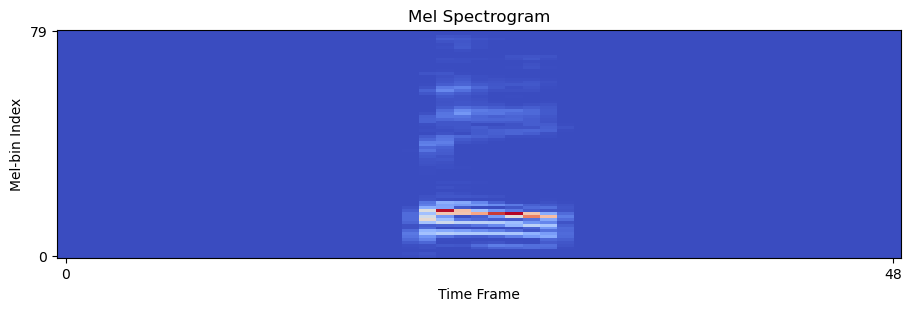

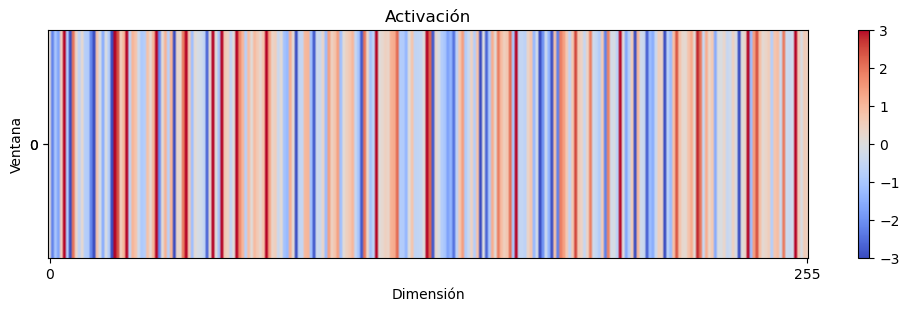

Audio(value=b'RIFFH\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

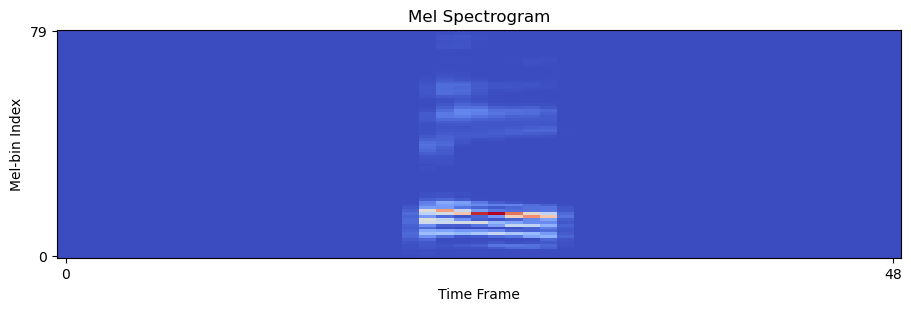

In [53]:
from cowaver.utils import extraer_waveform

it = iter(spoken_data.test_set)
(image, mel), target, task_id = next(it)

plot_mel(mel, should_show=False)
plt.savefig(f"{LANGUAGE}_spoken_word.svg")

display(audio_widget(extraer_waveform(mel)))

mel = mel.unsqueeze(1).transpose(2, 3)
with torch.no_grad():
    h = net.autoencoder.encode(mel.to(torch.device("mps")))
    mel_hat = net.autoencoder.decode(h)
predicted_mel = mel_hat.squeeze(1).transpose(1, 2)

plot_activation(h.detach().cpu())
plot_mel(predicted_mel)
display(audio_widget(extraer_waveform(predicted_mel.detach().cpu())))

En español:

```
Palabras entrenadas (480): Top-1: 100.00% | Top-3: 100.00% | Top-5: 100.00%
```

En frances:

```
Palabras entrenadas (480): Top-1: 97.08% | Top-3: 100.00% | Top-5: 100.00%
```

## Paired Autoencoder

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import LRScheduler, LinearLR

from cowaver.modules.adapters import build_temporal_adapter
from cowaver.modules.common import unpack_batch
from cowaver.modules.decoders import build_decoder
from cowaver.modules.encoders import AvgPooledITEncoder
from cowaver.models import DataModule, TestResults, TrainProgramme, TrainableModule
from cowaver.utils import distancia_mel
    
class PairedAutoencoder(TrainableModule):
    def __init__(self, seq_len: int = 49, mel_bins: int = 80):
        super().__init__(name=f"autoencoder_sl{seq_len}_mb{mel_bins}")
        self.seq_len = seq_len
        self.mel_bins = mel_bins
        self.autoencoder = ConvAutoEncoder(x_dim=(1, seq_len, mel_bins), h_dim=256, n_filters=32, filter_size=5)
        
    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        return self.autoencoder(x)

    def training_step(self, batch, batch_idx, phase: int):
        (x, phonetized_y, spoken_y), labels = batch
        B = x.size(0)
        phonetized_y = phonetized_y.transpose(2, 3)
        spoken_y = spoken_y.transpose(2, 3)
        y_hat = self(phonetized_y)
        return F.mse_loss(y_hat.reshape(B, -1), target=spoken_y.reshape(B, -1))

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (_, y_pho, _), targets = batch
        y_pho = y_pho.transpose(2, 3)
        y_hat = self(y_pho)
        y_hat = y_hat.squeeze(1).transpose(1, 2)
        prototypes = data.mel_prototypes(y_hat.device)
        distances = distancia_mel(y_hat, prototypes)

        k = min(5, distances.size(1))
        topk = distances.topk(k, dim=1, largest=False).indices

        targets = targets.view(-1, 1)

        top1 = (topk[:, :1] == targets).any(dim=1).sum().item()
        top3 = (topk[:, :min(3, k)] == targets).any(dim=1).sum().item()
        top5 = (topk[:, :k] == targets).any(dim=1).sum().item()

        return TestResults(top1=top1, top3=top3, top5=top5)

    def inference_step(self, batch: tuple) -> tuple[Tensor, Tensor]:
        x, _, _, task_ids = unpack_batch(batch)
        return self(x, task_ids=task_ids)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        trainable_params = filter(lambda p: p.requires_grad, self.parameters())
        return AdamW(params=trainable_params, lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        start_epoch = programme.epochs_before_phase(phase)
        for group in optimizer.param_groups:
            group.setdefault("initial_lr", group["lr"])
        return LinearLR(
            optimizer,
            start_factor=1.0,
            end_factor=programme.end_factor,
            total_iters=programme.decay_epochs(),
            last_epoch=start_epoch - 1,
        )

In [55]:
from cowaver.datamodules import TinyPairedMel
from cowaver.checkpoints import cargar_checkpoint
from cowaver.utils import evaluar_red

net = PairedAutoencoder()

cargar_checkpoint(net, folder=checkpoints_path / "spoken", silent=True)

for name, param in net.autoencoder.named_parameters():
    if name.startswith("dec_"):
        param.requires_grad = False

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)

programme = TrainProgramme(
    theta_max=30,
    num_phases=1,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4
)

# Uncomment to train
#
# train_history = entrenar_red(net=net, data=paired_data, programme=programme, phase=1, dispositivo=DEVICE)
# guardar_checkpoint(net, train_history=train_history, programme=programme, folder=checkpoints_path / "paired")

En español:

```
=================================================
Red autoencoder_sl49_mb80 | fase 1
=================================================
Epoch 1/30 | train_loss=1.4163 | val_loss=0.9075
Epoch 2/30 | train_loss=0.7020 | val_loss=0.6936
Epoch 3/30 | train_loss=0.4998 | val_loss=0.5904
Epoch 4/30 | train_loss=0.3793 | val_loss=0.5737
Epoch 5/30 | train_loss=0.3111 | val_loss=0.5247
Epoch 6/30 | train_loss=0.2595 | val_loss=0.4942
Epoch 7/30 | train_loss=0.2257 | val_loss=0.5003
Epoch 8/30 | train_loss=0.1989 | val_loss=0.4849
Epoch 9/30 | train_loss=0.1819 | val_loss=0.4817
Epoch 10/30 | train_loss=0.1623 | val_loss=0.4735
Epoch 11/30 | train_loss=0.1471 | val_loss=0.4686
Epoch 12/30 | train_loss=0.1350 | val_loss=0.4738
Epoch 13/30 | train_loss=0.1246 | val_loss=0.4738
Epoch 14/30 | train_loss=0.1177 | val_loss=0.4732
Epoch 15/30 | train_loss=0.1108 | val_loss=0.4710
Epoch 16/30 | train_loss=0.1043 | val_loss=0.4765
Epoch 17/30 | train_loss=0.0986 | val_loss=0.4709
Epoch 18/30 | train_loss=0.0942 | val_loss=0.4728
Epoch 19/30 | train_loss=0.0909 | val_loss=0.4738
Epoch 20/30 | train_loss=0.0887 | val_loss=0.4741
Epoch 21/30 | train_loss=0.0870 | val_loss=0.4744
Epoch 22/30 | train_loss=0.0863 | val_loss=0.4767
Epoch 23/30 | train_loss=0.0857 | val_loss=0.4760
Epoch 24/30 | train_loss=0.0851 | val_loss=0.4769
Epoch 25/30 | train_loss=0.0846 | val_loss=0.4775
Epoch 26/30 | train_loss=0.0840 | val_loss=0.4791
Epoch 27/30 | train_loss=0.0835 | val_loss=0.4799
Epoch 28/30 | train_loss=0.0830 | val_loss=0.4797
Epoch 29/30 | train_loss=0.0825 | val_loss=0.4804
Epoch 30/30 | train_loss=0.0820 | val_loss=0.4822
Phase 1 | test_loss=0.3736
Guardando checkpoint en ../spanish/480/checkpoints/paired/autoencoder_sl49_mb80_1st_phase.pt... OK
```


En francés:

```
=================================================
Red autoencoder_sl49_mb80 | fase 1
=================================================
Epoch 1/30 | train_loss=2.2463 | val_loss=1.5592
Epoch 2/30 | train_loss=1.2149 | val_loss=1.1337
Epoch 3/30 | train_loss=0.7653 | val_loss=0.9145
Epoch 4/30 | train_loss=0.5408 | val_loss=0.8134
Epoch 5/30 | train_loss=0.4129 | val_loss=0.7664
Epoch 6/30 | train_loss=0.3236 | val_loss=0.7172
Epoch 7/30 | train_loss=0.2771 | val_loss=0.7195
Epoch 8/30 | train_loss=0.2359 | val_loss=0.6960
Epoch 9/30 | train_loss=0.2012 | val_loss=0.6748
Epoch 10/30 | train_loss=0.1758 | val_loss=0.6793
Epoch 11/30 | train_loss=0.1585 | val_loss=0.6571
Epoch 12/30 | train_loss=0.1428 | val_loss=0.6517
Epoch 13/30 | train_loss=0.1250 | val_loss=0.6582
Epoch 14/30 | train_loss=0.1123 | val_loss=0.6506
Epoch 15/30 | train_loss=0.1031 | val_loss=0.6533
Epoch 16/30 | train_loss=0.0936 | val_loss=0.6544
Epoch 17/30 | train_loss=0.0843 | val_loss=0.6564
Epoch 18/30 | train_loss=0.0767 | val_loss=0.6497
Epoch 19/30 | train_loss=0.0711 | val_loss=0.6565
Epoch 20/30 | train_loss=0.0666 | val_loss=0.6534
Epoch 21/30 | train_loss=0.0636 | val_loss=0.6573
Epoch 22/30 | train_loss=0.0624 | val_loss=0.6544
Epoch 23/30 | train_loss=0.0614 | val_loss=0.6592
Epoch 24/30 | train_loss=0.0605 | val_loss=0.6585
Epoch 25/30 | train_loss=0.0597 | val_loss=0.6576
Epoch 26/30 | train_loss=0.0589 | val_loss=0.6606
Epoch 27/30 | train_loss=0.0581 | val_loss=0.6615
Epoch 28/30 | train_loss=0.0573 | val_loss=0.6617
Epoch 29/30 | train_loss=0.0566 | val_loss=0.6668
Epoch 30/30 | train_loss=0.0559 | val_loss=0.6666
Phase 1 | test_loss=0.4827
Guardando checkpoint en ../french/480/checkpoints/paired/autoencoder_sl49_mb80_1st_phase.pt... OK
```

Palabras entrenadas (384): Top-1: 87.50% | Top-3: 93.49% | Top-5: 94.53%
Palabras no vistas (96): Top-1: 10.42% | Top-3: 28.12% | Top-5: 32.29%


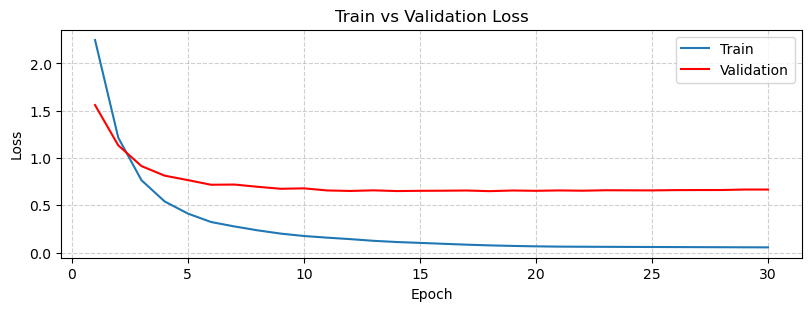

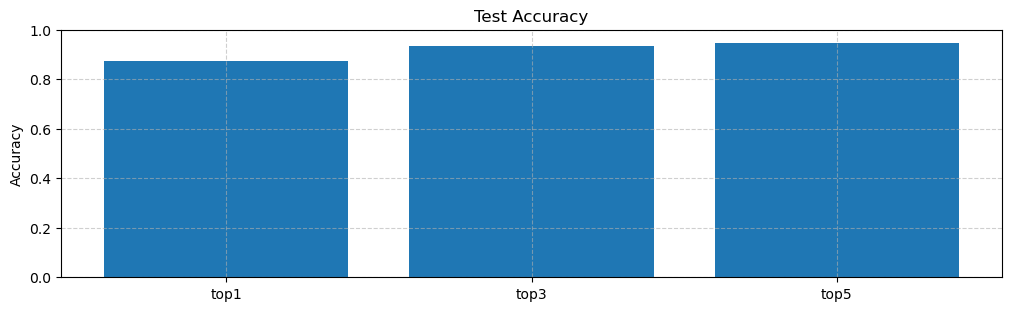

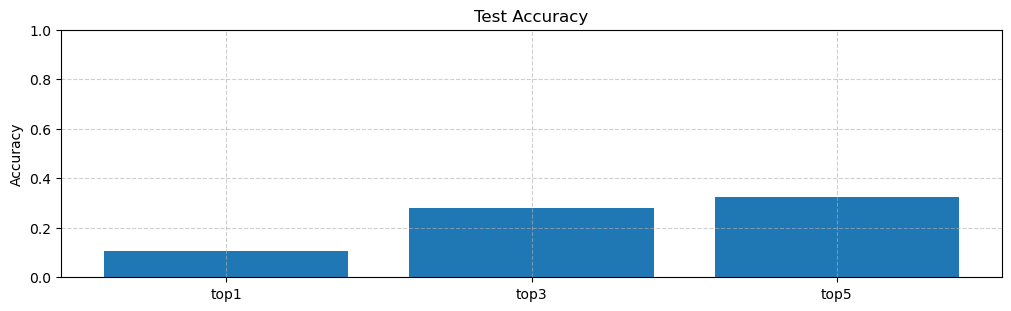

In [56]:
from cowaver.datamodules import TinyPairedMel

net = PairedAutoencoder()
train_history = cargar_checkpoint(net, folder=checkpoints_path / "paired", silent=True)
plot_train_history(train_history, should_show=False)
plt.savefig(f"{LANGUAGE}_phonological_awareness_train.svg")
cross_language_results[LANGUAGE]["phonological_awareness_train"] = train_history

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)
test_results = evaluar_red(net, paired_data)
print(f"Palabras entrenadas ({int(DATASET_SIZE * 0.8)}): {test_results}")

plot_test_results(test_results, should_show=False)
plt.savefig(f"{LANGUAGE}_phonological_awareness_test.svg")
cross_language_results[LANGUAGE]["phonological_awareness_test"] = test_results

data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_generalizar)
test_results = evaluar_red(net, data)
print(f"Palabras no vistas ({int(DATASET_SIZE * 0.2)}): {test_results}")

plot_test_results(test_results, should_show=False)
plt.savefig(f"{LANGUAGE}_phonological_awareness_heldout_test.svg")
cross_language_results[LANGUAGE]["phonological_awareness_heldout_test"] = test_results

Audio(value=b'RIFFH\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

Audio(value=b'RIFFH\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

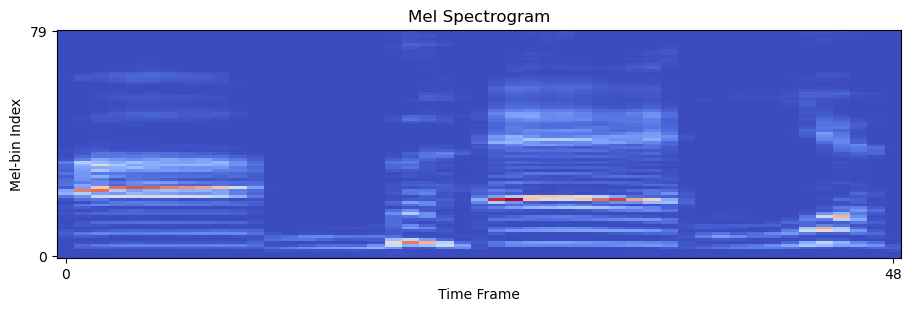

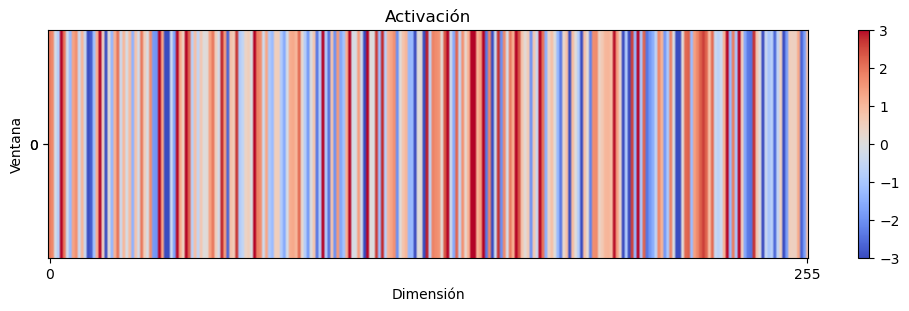

Audio(value=b'RIFFH\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

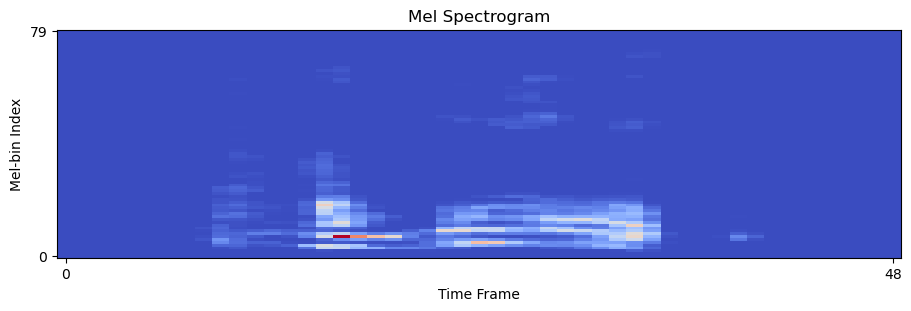

In [57]:
from cowaver.utils import extraer_waveform

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80)

it = iter(paired_data.test_set)
(image, phonetized_mel, spoken_mel), target = next(it)

plot_mel(phonetized_mel, should_show=False)
plt.savefig(f"{LANGUAGE}_phonetized_word.svg")

display(audio_widget(extraer_waveform(phonetized_mel)))
display(audio_widget(extraer_waveform(spoken_mel)))

phonetized_mel = phonetized_mel.unsqueeze(1).transpose(2, 3)
with torch.no_grad():
    h = net.autoencoder.encode(phonetized_mel.to(torch.device("mps")))
    mel_hat = net.autoencoder.decode(h)
predicted_mel = mel_hat.squeeze(1).transpose(1, 2)

plot_activation(h.detach().cpu())
plot_mel(predicted_mel)
display(audio_widget(extraer_waveform(predicted_mel.detach().cpu() * 2)))

En español:

```
Palabras entrenadas (384): Top-1: 94.01% | Top-3: 96.35% | Top-5: 96.88%
Palabras no vistas (96): Top-1: 47.92% | Top-3: 60.42% | Top-5: 67.71%
```

En francés:

```
Palabras entrenadas (384): Top-1: 85.16% | Top-3: 90.89% | Top-5: 91.93%
Palabras no vistas (96): Top-1: 10.42% | Top-3: 28.12% | Top-5: 32.29%
```

In [58]:
from cowaver.modules.encoders import AvgPooledITEncoder

net = PairedAutoencoder()
cargar_checkpoint(net, folder=checkpoints_path / "paired", silent=True)
net = net.to(torch.device("mps"))
net.eval()

class VisualEncoder(TrainableModule):
    def __init__(self, h_dim=256):
        super().__init__(name=f"visual_encoder_hd{h_dim}")
        self.h_dim = h_dim
        self.encoder = AvgPooledITEncoder()
        self.rnn = nn.RNN(
            input_size=512,
            hidden_size=256,
            nonlinearity='tanh',
            batch_first=True,
            bidirectional=False
        )
        self.proj = nn.Linear(256, h_dim)

        self.register_buffer('h_mean', torch.zeros(h_dim))
        self.register_buffer('h_std', torch.ones(h_dim))
        
    def forward(self, x: Tensor) -> Tensor:
        # x = [32, 3, 224, 224]
        h = self.encoder(x)
        # h = [32, 7, 512]
        out, h_n = self.rnn(h)
        return self.proj(h_n[0])

    def training_step(self, batch, batch_idx, phase: int):
        (x, y, _), labels = batch
        y = y.transpose(2, 3)
        with torch.no_grad():
            h = net.autoencoder.encode(y)
            h_norm = (h - self.h_mean) / (self.h_std + 1e-6)
            
        h_hat_norm = self(x)
        return F.mse_loss(h_norm, h_hat_norm)

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (x, _, y), targets = batch
        h_hat_norm = self(x)
        h_hat = h_hat_norm * self.h_std + self.h_mean
        mel_hat = net.autoencoder.decode(h_hat)
        mel_hat = mel_hat.squeeze(1).transpose(1, 2)
        
        prototypes = data.mel_prototypes(mel_hat.device)

        distances = distancia_mel(mel_hat, prototypes)

        k = min(5, distances.size(1))
        topk = distances.topk(k, dim=1, largest=False).indices

        targets = targets.view(-1, 1)

        top1 = (topk[:, :1] == targets).any(dim=1).sum().item()
        top3 = (topk[:, :min(3, k)] == targets).any(dim=1).sum().item()
        top5 = (topk[:, :k] == targets).any(dim=1).sum().item()

        return TestResults(top1=top1, top3=top3, top5=top5)

    def inference_step(self, batch: tuple) -> tuple[Tensor, Tensor]:
        x, _, _, task_ids = unpack_batch(batch)
        return self(x, task_ids=task_ids)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        return AdamW(params=self.parameters(), lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        start_epoch = programme.epochs_before_phase(phase)
        for group in optimizer.param_groups:
            group.setdefault("initial_lr", group["lr"])
        return LinearLR(
            optimizer,
            start_factor=1.0,
            end_factor=programme.end_factor,
            total_iters=programme.decay_epochs(),
            last_epoch=start_epoch - 1,
        )

    def set_h_stats(self, h_mean: Tensor, h_std: Tensor):
        """Llamar una vez, antes de entrenar, con las stats reales del dataset."""
        self.h_mean.copy_(h_mean)
        self.h_std.copy_(h_std)

In [59]:
from cowaver.checkpoints import cargar_checkpoint, guardar_checkpoint
from cowaver.utils import entrenar_red

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)

visual_encoder = VisualEncoder()

all_h = []
net.autoencoder.eval()
with torch.no_grad():
    for batch in paired_data.train_loader():
        (_, y, _), labels = batch
        y = y.transpose(2, 3)
        y = y.to("mps")
        h = net.autoencoder.encode(y)
        all_h.append(h)
all_h = torch.cat(all_h, dim=0)
h_mean = all_h.mean(dim=0)   # [256]
h_std = all_h.std(dim=0)     # [256]
visual_encoder.set_h_stats(h_mean, h_std)


programme = TrainProgramme(
    theta_max=60,
    num_phases=1,
    epsilon_zero=1e-3,
    theta=45,
    epsilon_theta=1e-4
)

# Uncomment to train
#
# train_history = entrenar_red(net=visual_encoder, data=paired_data, programme=programme, phase=1, dispositivo=DEVICE)
# guardar_checkpoint(visual_encoder, train_history=train_history, programme=programme, folder=checkpoints_path / "visual")

En español:

```
=================================================
Red visual_encoder_hd256 | fase 1
=================================================
Epoch 1/60 | train_loss=0.9415 | val_loss=0.6962
Epoch 2/60 | train_loss=0.7751 | val_loss=0.5933
Epoch 3/60 | train_loss=0.6656 | val_loss=0.5406
Epoch 4/60 | train_loss=0.5980 | val_loss=0.5031
Epoch 5/60 | train_loss=0.5554 | val_loss=0.4794
Epoch 6/60 | train_loss=0.5266 | val_loss=0.4681
Epoch 7/60 | train_loss=0.5058 | val_loss=0.4638
Epoch 8/60 | train_loss=0.4919 | val_loss=0.4569
Epoch 9/60 | train_loss=0.4806 | val_loss=0.4510
Epoch 10/60 | train_loss=0.4718 | val_loss=0.4491
Epoch 11/60 | train_loss=0.4659 | val_loss=0.4427
Epoch 12/60 | train_loss=0.4595 | val_loss=0.4445
Epoch 13/60 | train_loss=0.4564 | val_loss=0.4437
Epoch 14/60 | train_loss=0.4522 | val_loss=0.4372
Epoch 15/60 | train_loss=0.4479 | val_loss=0.4377
Epoch 16/60 | train_loss=0.4455 | val_loss=0.4371
Epoch 17/60 | train_loss=0.4423 | val_loss=0.4375
Epoch 18/60 | train_loss=0.4412 | val_loss=0.4345
Epoch 19/60 | train_loss=0.4378 | val_loss=0.4340
Epoch 20/60 | train_loss=0.4355 | val_loss=0.4332
Epoch 21/60 | train_loss=0.4338 | val_loss=0.4319
Epoch 22/60 | train_loss=0.4332 | val_loss=0.4326
Epoch 23/60 | train_loss=0.4310 | val_loss=0.4313
Epoch 24/60 | train_loss=0.4289 | val_loss=0.4310
Epoch 25/60 | train_loss=0.4281 | val_loss=0.4320
Epoch 26/60 | train_loss=0.4268 | val_loss=0.4298
Epoch 27/60 | train_loss=0.4254 | val_loss=0.4296
Epoch 28/60 | train_loss=0.4237 | val_loss=0.4275
Epoch 29/60 | train_loss=0.4227 | val_loss=0.4292
Epoch 30/60 | train_loss=0.4216 | val_loss=0.4280
Epoch 31/60 | train_loss=0.4204 | val_loss=0.4270
Epoch 32/60 | train_loss=0.4195 | val_loss=0.4269
Epoch 33/60 | train_loss=0.4180 | val_loss=0.4262
Epoch 34/60 | train_loss=0.4175 | val_loss=0.4264
Epoch 35/60 | train_loss=0.4160 | val_loss=0.4258
Epoch 36/60 | train_loss=0.4155 | val_loss=0.4244
Epoch 37/60 | train_loss=0.4144 | val_loss=0.4251
Epoch 38/60 | train_loss=0.4136 | val_loss=0.4243
Epoch 39/60 | train_loss=0.4128 | val_loss=0.4235
Epoch 40/60 | train_loss=0.4112 | val_loss=0.4243
Epoch 41/60 | train_loss=0.4102 | val_loss=0.4232
Epoch 42/60 | train_loss=0.4096 | val_loss=0.4227
Epoch 43/60 | train_loss=0.4084 | val_loss=0.4219
Epoch 44/60 | train_loss=0.4076 | val_loss=0.4218
Epoch 45/60 | train_loss=0.4067 | val_loss=0.4211
Epoch 46/60 | train_loss=0.4061 | val_loss=0.4216
Epoch 47/60 | train_loss=0.4054 | val_loss=0.4209
Epoch 48/60 | train_loss=0.4056 | val_loss=0.4206
Epoch 49/60 | train_loss=0.4057 | val_loss=0.4212
Epoch 50/60 | train_loss=0.4055 | val_loss=0.4209
Epoch 51/60 | train_loss=0.4052 | val_loss=0.4205
Epoch 52/60 | train_loss=0.4053 | val_loss=0.4211
Epoch 53/60 | train_loss=0.4051 | val_loss=0.4211
Epoch 54/60 | train_loss=0.4052 | val_loss=0.4209
Epoch 55/60 | train_loss=0.4049 | val_loss=0.4202
Epoch 56/60 | train_loss=0.4053 | val_loss=0.4208
Epoch 57/60 | train_loss=0.4050 | val_loss=0.4210
Epoch 58/60 | train_loss=0.4051 | val_loss=0.4208
Epoch 59/60 | train_loss=0.4047 | val_loss=0.4215
Epoch 60/60 | train_loss=0.4046 | val_loss=0.4211
Phase 1 | test_loss=0.5216
Guardando checkpoint en ../spanish/checkpoints/480/visual/visual_encoder_hd256_1st_phase.pt... OK
```

En francés:

```
=================================================
Red visual_encoder_hd256 | fase 1
=================================================
Epoch 1/60 | train_loss=0.7697 | val_loss=0.5525
Epoch 2/60 | train_loss=0.6235 | val_loss=0.4779
Epoch 3/60 | train_loss=0.5201 | val_loss=0.4272
Epoch 4/60 | train_loss=0.4567 | val_loss=0.4015
Epoch 5/60 | train_loss=0.4197 | val_loss=0.3848
Epoch 6/60 | train_loss=0.3940 | val_loss=0.3761
Epoch 7/60 | train_loss=0.3764 | val_loss=0.3683
Epoch 8/60 | train_loss=0.3631 | val_loss=0.3652
Epoch 9/60 | train_loss=0.3537 | val_loss=0.3632
Epoch 10/60 | train_loss=0.3462 | val_loss=0.3570
Epoch 11/60 | train_loss=0.3395 | val_loss=0.3559
Epoch 12/60 | train_loss=0.3345 | val_loss=0.3568
Epoch 13/60 | train_loss=0.3303 | val_loss=0.3521
Epoch 14/60 | train_loss=0.3270 | val_loss=0.3508
Epoch 15/60 | train_loss=0.3234 | val_loss=0.3477
Epoch 16/60 | train_loss=0.3210 | val_loss=0.3489
Epoch 17/60 | train_loss=0.3188 | val_loss=0.3482
Epoch 18/60 | train_loss=0.3163 | val_loss=0.3483
Epoch 19/60 | train_loss=0.3145 | val_loss=0.3469
Epoch 20/60 | train_loss=0.3122 | val_loss=0.3467
Epoch 21/60 | train_loss=0.3112 | val_loss=0.3468
Epoch 22/60 | train_loss=0.3098 | val_loss=0.3464
Epoch 23/60 | train_loss=0.3081 | val_loss=0.3431
Epoch 24/60 | train_loss=0.3066 | val_loss=0.3427
Epoch 25/60 | train_loss=0.3058 | val_loss=0.3442
Epoch 26/60 | train_loss=0.3050 | val_loss=0.3416
Epoch 27/60 | train_loss=0.3035 | val_loss=0.3424
Epoch 28/60 | train_loss=0.3026 | val_loss=0.3424
Epoch 29/60 | train_loss=0.3014 | val_loss=0.3407
Epoch 30/60 | train_loss=0.3001 | val_loss=0.3416
Epoch 31/60 | train_loss=0.2994 | val_loss=0.3404
Epoch 32/60 | train_loss=0.2984 | val_loss=0.3404
Epoch 33/60 | train_loss=0.2978 | val_loss=0.3402
Epoch 34/60 | train_loss=0.2969 | val_loss=0.3407
Epoch 35/60 | train_loss=0.2960 | val_loss=0.3394
Epoch 36/60 | train_loss=0.2948 | val_loss=0.3385
Epoch 37/60 | train_loss=0.2941 | val_loss=0.3380
Epoch 38/60 | train_loss=0.2933 | val_loss=0.3378
Epoch 39/60 | train_loss=0.2925 | val_loss=0.3371
Epoch 40/60 | train_loss=0.2914 | val_loss=0.3362
Epoch 41/60 | train_loss=0.2907 | val_loss=0.3368
Epoch 42/60 | train_loss=0.2900 | val_loss=0.3364
Epoch 43/60 | train_loss=0.2893 | val_loss=0.3356
Epoch 44/60 | train_loss=0.2884 | val_loss=0.3359
Epoch 45/60 | train_loss=0.2875 | val_loss=0.3348
Epoch 46/60 | train_loss=0.2870 | val_loss=0.3348
Epoch 47/60 | train_loss=0.2866 | val_loss=0.3349
Epoch 48/60 | train_loss=0.2867 | val_loss=0.3346
Epoch 49/60 | train_loss=0.2866 | val_loss=0.3346
Epoch 50/60 | train_loss=0.2866 | val_loss=0.3350
Epoch 51/60 | train_loss=0.2865 | val_loss=0.3346
Epoch 52/60 | train_loss=0.2864 | val_loss=0.3348
Epoch 53/60 | train_loss=0.2863 | val_loss=0.3347
Epoch 54/60 | train_loss=0.2864 | val_loss=0.3349
Epoch 55/60 | train_loss=0.2863 | val_loss=0.3348
Epoch 56/60 | train_loss=0.2863 | val_loss=0.3344
Epoch 57/60 | train_loss=0.2862 | val_loss=0.3347
Epoch 58/60 | train_loss=0.2862 | val_loss=0.3347
Epoch 59/60 | train_loss=0.2860 | val_loss=0.3351
Epoch 60/60 | train_loss=0.2860 | val_loss=0.3346
Phase 1 | test_loss=nan
```

Entrenamiento viejo sobre 500/450:

```
=================================================
Red visual_encoder_hd256 | fase 1
=================================================
Epoch 1/60 | train_loss=0.7404 | val_loss=0.5349
Epoch 2/60 | train_loss=0.6126 | val_loss=0.4560
Epoch 3/60 | train_loss=0.5359 | val_loss=0.4219
Epoch 4/60 | train_loss=0.4910 | val_loss=0.4010
Epoch 5/60 | train_loss=0.4631 | val_loss=0.3906
Epoch 6/60 | train_loss=0.4448 | val_loss=0.3845
Epoch 7/60 | train_loss=0.4330 | val_loss=0.3804
Epoch 8/60 | train_loss=0.4234 | val_loss=0.3772
Epoch 9/60 | train_loss=0.4167 | val_loss=0.3755
Epoch 10/60 | train_loss=0.4118 | val_loss=0.3732
Epoch 11/60 | train_loss=0.4077 | val_loss=0.3746
Epoch 12/60 | train_loss=0.4032 | val_loss=0.3729
Epoch 13/60 | train_loss=0.4006 | val_loss=0.3698
Epoch 14/60 | train_loss=0.3979 | val_loss=0.3686
Epoch 15/60 | train_loss=0.3956 | val_loss=0.3680
Epoch 16/60 | train_loss=0.3937 | val_loss=0.3672
Epoch 17/60 | train_loss=0.3924 | val_loss=0.3656
Epoch 18/60 | train_loss=0.3906 | val_loss=0.3661
Epoch 19/60 | train_loss=0.3891 | val_loss=0.3657
Epoch 20/60 | train_loss=0.3873 | val_loss=0.3649
Epoch 21/60 | train_loss=0.3865 | val_loss=0.3647
Epoch 22/60 | train_loss=0.3850 | val_loss=0.3660
Epoch 23/60 | train_loss=0.3843 | val_loss=0.3634
Epoch 24/60 | train_loss=0.3826 | val_loss=0.3633
Epoch 25/60 | train_loss=0.3817 | val_loss=0.3620
Epoch 26/60 | train_loss=0.3804 | val_loss=0.3612
Epoch 27/60 | train_loss=0.3794 | val_loss=0.3611
Epoch 28/60 | train_loss=0.3788 | val_loss=0.3615
Epoch 29/60 | train_loss=0.3781 | val_loss=0.3613
Epoch 30/60 | train_loss=0.3762 | val_loss=0.3612
Epoch 31/60 | train_loss=0.3761 | val_loss=0.3608
Epoch 32/60 | train_loss=0.3749 | val_loss=0.3593
Epoch 33/60 | train_loss=0.3737 | val_loss=0.3592
Epoch 34/60 | train_loss=0.3730 | val_loss=0.3583
Epoch 35/60 | train_loss=0.3723 | val_loss=0.3585
Epoch 36/60 | train_loss=0.3711 | val_loss=0.3587
Epoch 37/60 | train_loss=0.3711 | val_loss=0.3576
Epoch 38/60 | train_loss=0.3701 | val_loss=0.3573
Epoch 39/60 | train_loss=0.3691 | val_loss=0.3564
Epoch 40/60 | train_loss=0.3682 | val_loss=0.3567
Epoch 41/60 | train_loss=0.3673 | val_loss=0.3568
Epoch 42/60 | train_loss=0.3667 | val_loss=0.3562
Epoch 43/60 | train_loss=0.3654 | val_loss=0.3564
Epoch 44/60 | train_loss=0.3647 | val_loss=0.3557
Epoch 45/60 | train_loss=0.3641 | val_loss=0.3546
Epoch 46/60 | train_loss=0.3635 | val_loss=0.3547
Epoch 47/60 | train_loss=0.3631 | val_loss=0.3544
Epoch 48/60 | train_loss=0.3633 | val_loss=0.3546
Epoch 49/60 | train_loss=0.3628 | val_loss=0.3546
Epoch 50/60 | train_loss=0.3631 | val_loss=0.3549
Epoch 51/60 | train_loss=0.3632 | val_loss=0.3548
Epoch 52/60 | train_loss=0.3631 | val_loss=0.3548
Epoch 53/60 | train_loss=0.3632 | val_loss=0.3548
Epoch 54/60 | train_loss=0.3628 | val_loss=0.3549
Epoch 55/60 | train_loss=0.3628 | val_loss=0.3552
Epoch 56/60 | train_loss=0.3632 | val_loss=0.3546
Epoch 57/60 | train_loss=0.3627 | val_loss=0.3549
Epoch 58/60 | train_loss=0.3628 | val_loss=0.3549
Epoch 59/60 | train_loss=0.3626 | val_loss=0.3546
Epoch 60/60 | train_loss=0.3627 | val_loss=0.3547
Phase 1 | test_loss=0.2446
```

Palabras entrenadas (384): Top-1: 97.92% | Top-3: 100.00% | Top-5: 100.00%
Palabras no vistas (96): Top-1: 8.33% | Top-3: 15.62% | Top-5: 21.88%


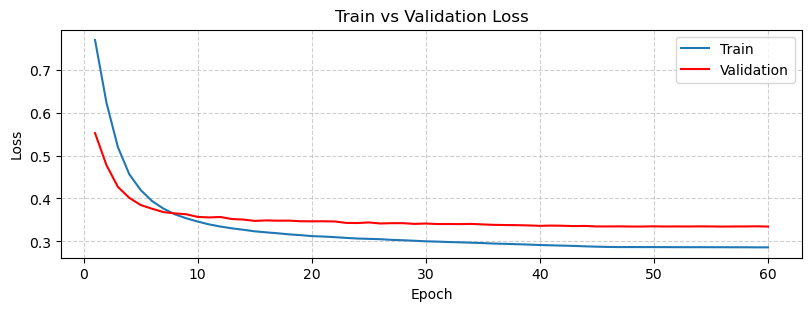

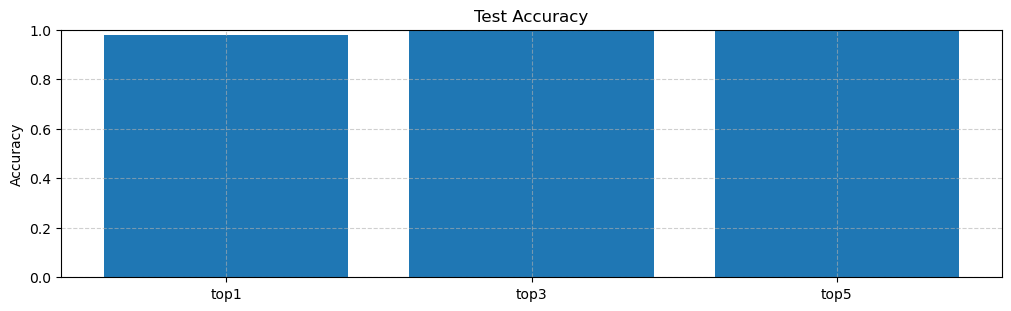

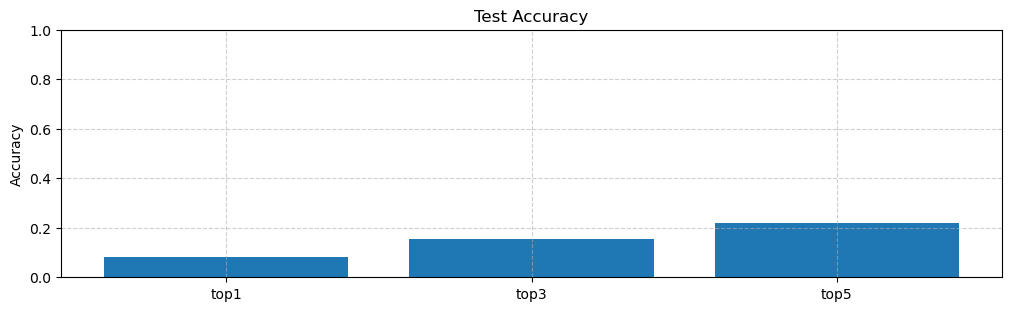

In [60]:
visual_encoder = VisualEncoder()
train_history = cargar_checkpoint(visual_encoder, folder=checkpoints_path / "visual", silent=True)
plot_train_history(train_history, should_show=False)
plt.savefig(f"{LANGUAGE}_visual_train.svg")
cross_language_results[LANGUAGE]["visual_train"] = train_history

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)
test_results = evaluar_red(visual_encoder, paired_data)
print(f"Palabras entrenadas ({int(DATASET_SIZE * 0.8)}): {test_results}")

plot_test_results(test_results, should_show=False)
plt.savefig(f"{LANGUAGE}_visual_test.svg")
cross_language_results[LANGUAGE]["visual_test"] = test_results

data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_generalizar)
test_results = evaluar_red(visual_encoder, data)
print(f"Palabras no vistas ({int(DATASET_SIZE * 0.2)}): {test_results}")

plot_test_results(test_results, should_show=False)
plt.savefig(f"{LANGUAGE}_visual_heldout_test.svg")
cross_language_results[LANGUAGE]["visual_held_out_test"] = test_results

In [61]:
print(palabras_a_generalizar)

['abeille', 'aigle', 'aile', 'après', 'arc', 'assise', 'auto', 'avez', 'avion', 'base', 'bien', 'bête', 'cage', 'chasse', 'chaud', 'cirque', 'colle', 'colère', 'cousin', 'dent', 'devant', 'domino', 'doux', 'désert', 'filet', 'fine', 'foyer', 'gagnant', 'gagné', 'gare', 'grotte', 'guide', 'jambe', 'jardin', 'jouant', 'jour', 'karaté', 'leçon', 'loup', 'lundi', 'malade', 'marine', 'masque', 'monstre', 'moule', 'mousse', 'météo', 'neveu', 'niche', 'niveau', 'noté', 'noyer', 'nul', 'onze', 'ours', 'passé', 'pendant', 'perdu', 'petit', 'phrase', 'piano', 'pin', 'piqué', 'pirate', 'porte', 'porter', 'pâte', 'quart', 'que', 'radio', 'reine', 'renard', 'reste', 'riant', 'rouge', 'savoir', 'ses', 'soleil', 'station', 'sujet', 'sèche', 'tard', 'taxi', 'tes', 'toi', 'toit', 'trésor', 'tôt', 'usine', 'vite', 'voici', 'volant', 'vole', 'zéro', 'étage', 'être']


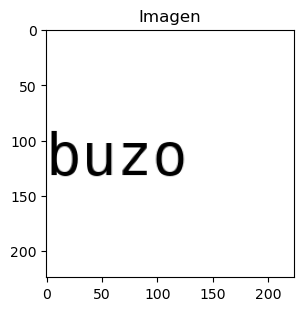

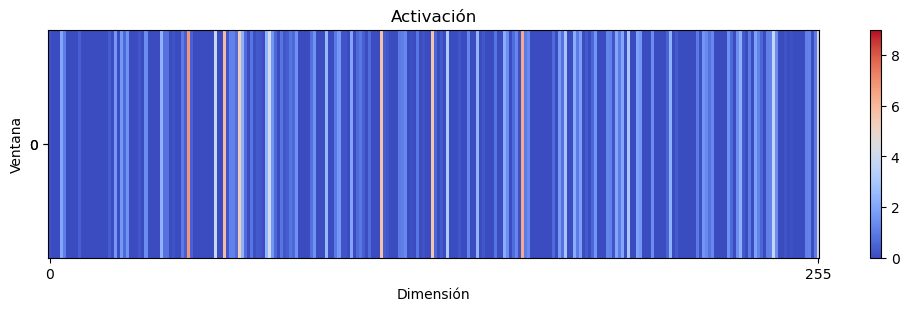

Audio(value=b'RIFFH\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00 \…

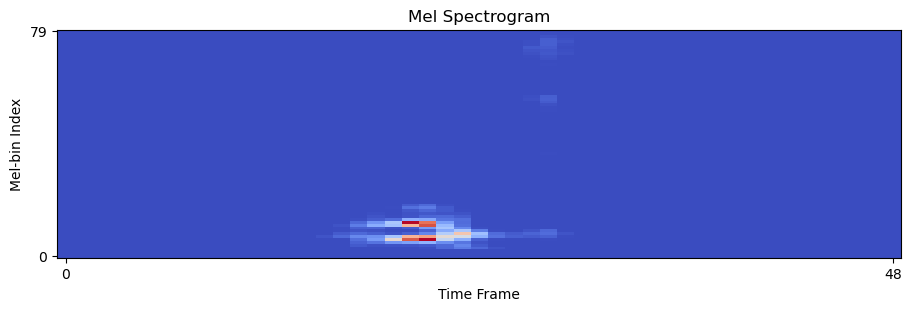

In [62]:
from cowaver.utils import make_image

image = make_image("buzo", x_stride=0)
plot_image(image)

with torch.no_grad():
    image = image.to("mps")
    h_hat_norm = visual_encoder(image)
    h_hat = h_hat_norm * visual_encoder.h_std + visual_encoder.h_mean
    mel_hat = net.autoencoder.decode(h_hat)
predicted_mel = mel_hat.squeeze(1).transpose(1, 2)

# plot_activation(net.autoencoder.encode(mel.unsqueeze(1).transpose(2, 3).to("mps")).detach().cpu(), vmin=-9, vmax=9)
plot_activation(h_hat.detach().cpu(), vmin=-0, vmax=9)

plot_mel(predicted_mel)
display(audio_widget(extraer_waveform(predicted_mel.detach().cpu())))

En español:

```
Palabras entrenadas (384): Top-1: 99.74% | Top-3: 100.00% | Top-5: 100.00%
Palabras no vistas (96): Top-1: 19.79% | Top-3: 41.67% | Top-5: 50.00%
```


En francés:

```
Palabras entrenadas (384): Top-1: 97.92% | Top-3: 100.00% | Top-5: 100.00%
Palabras no vistas (96): Top-1: 8.33% | Top-3: 15.62% | Top-5: 21.88%
```

## Plots

In [208]:
import seaborn as sns
import pandas as pd

def plot_losses(label: str):
    rows = []
    
    for lang in ["Spanish", "French"]:
        results = cross_language_results[lang.lower()][f"{label}_train"]
    
        for epoch, (train_loss, val_loss) in enumerate(
            zip(results.train_losses, results.val_losses)
        ):
            rows.extend(
                [
                    {
                        "Language": lang,
                        "Epoch": epoch,
                        "Loss Type": "Train Loss",
                        "Loss": train_loss,
                    },
                    {
                        "Language": lang,
                        "Epoch": epoch,
                        "Loss Type": "Validation Loss",
                        "Loss": val_loss,
                    },
                ]
            )
    
    plot_df = pd.DataFrame(rows)

    sns.set_context("poster")
    
    g = sns.relplot(
        data=plot_df,
        x="Epoch",
        y="Loss",
        hue="Loss Type",
        col="Language",
        kind="line",
        errorbar=None,
        alpha=0.8,
        height=6,
        facet_kws={"sharey": True},
    )
    
    g.set_axis_labels("Epoch", "Loss")
    g.set_titles("{col_name}")
    return g

In [220]:
import seaborn as sns
import pandas as pd

def plot_accuracies(label: str, sets: list):
    language = []
    top = []
    accuracy = []
    word_set = []
    for lang in ["Spanish", "French"]:
        for word_s in sets:
            if label == "visual":
                word_set_suffix = "test" if "Train" in word_s else "held_out_test"
            elif label == "phonological_awareness":
                word_set_suffix = "test" if "Train" in word_s else "heldout_test"
            else:
                word_set_suffix = "test"
            word_set.extend([word_s, word_s, word_s])
            language.extend([lang, lang, lang])
            top.extend(["Top-1", "Top-3", "Top-5"])
            accuracy.append(cross_language_results[lang.lower()][f"{label}_{word_set_suffix}"].top1 * 100)
            accuracy.append(cross_language_results[lang.lower()][f"{label}_{word_set_suffix}"].top3 * 100)
            accuracy.append(cross_language_results[lang.lower()][f"{label}_{word_set_suffix}"].top5 * 100)
    
    df = pd.DataFrame(
        {
            "Language": language,
            "Top-k": top,
            "Accuracy (%)": accuracy,
            "Set": word_set
        }
    )

    sns.set_context("poster")
    g = sns.catplot(
        data=df, 
        kind="bar", 
        x="Language",
        y="Accuracy (%)", 
        hue="Top-k", 
        palette="Reds_r", 
        col="Set",
        alpha=.6, 
        height=6
    )
    g.set_axis_labels("Language", "Accuracy (%)")
    return g

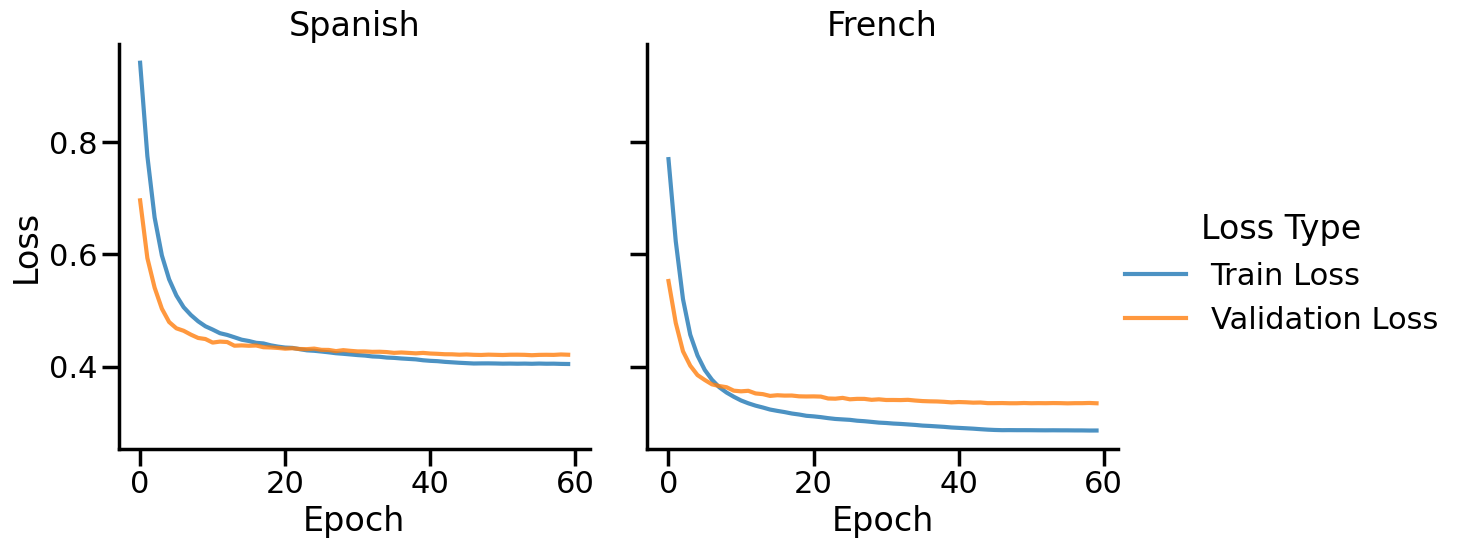

In [207]:
plot_losses("visual")

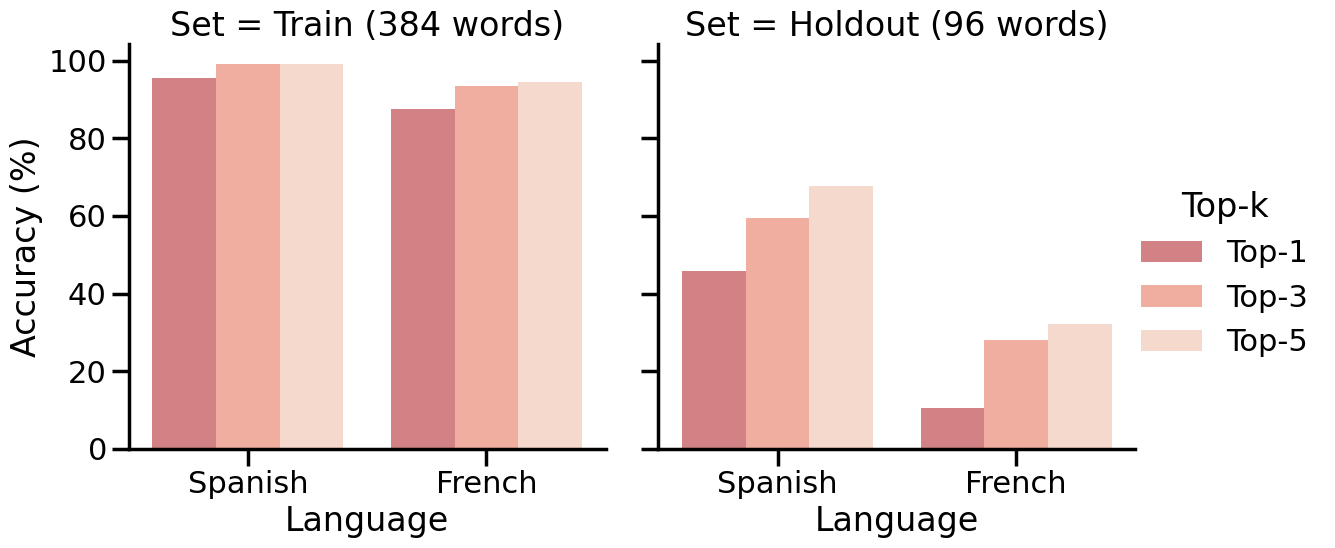

In [225]:
sets = [f"Train ({int(DATASET_SIZE * 0.8)} words)", f"Holdout ({int(DATASET_SIZE * 0.2)} words)"]
#g = plot_accuracies("autoencoder", [f"Full ({int(DATASET_SIZE)} words)"])
g = plot_accuracies("phonological_awareness", sets)
# g = plot_accuracies("visual", sets)
g.savefig(
    "phonological_awareness_test.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight"
)
#
#plot_accuracies("visual", sets)